#### Task 1: Load CIFAR 10

In [42]:
# Import dependencies
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import random_split

In [2]:
# Load Image Transform
transform = transforms.ToTensor()

In [3]:
# Load Train dataset
train_dataset = torchvision.datasets.CIFAR10(
    root = './data',
    download = True,
    train = True,
    transform = transform
)

100%|██████████| 170M/170M [28:49<00:00, 98.6kB/s]


In [43]:
# Validation Dataset
train_size = 45000
validation_size = 5000

train_subset, validation_subset = random_split(
    train_dataset,
    [train_size, validation_size]
)

In [4]:
# Load Test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root = './data',
    download = True,
    train = False,
    transform = transform
)

In [5]:
# Print Dataset Dimensions
print("Training Datset: ", len(train_dataset))
print("Test Datset: ", len(test_dataset))

image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)

Training Datset:  50000
Test Datset:  10000
Image Shape : torch.Size([3, 32, 32])
Label : 6


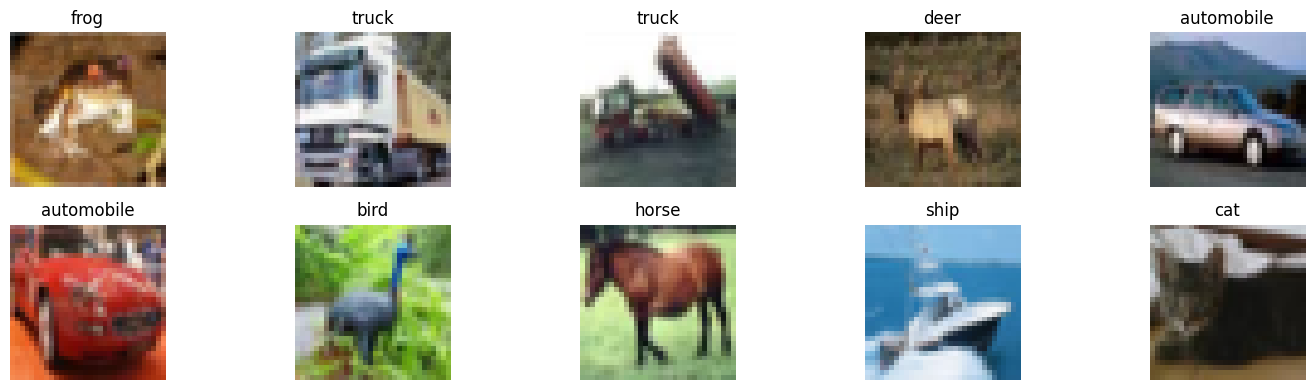

In [6]:
# Display first 10 images
classes = train_dataset.classes

plt.figure(figsize = (15,4))

for i in range(10):
  image, label = train_dataset[i]

  plt.subplot(2, 5, i + 1)

  image = image.permute(1, 2, 0)

  plt.imshow(image)
  plt.title(classes[label])
  plt.axis("off")

plt.tight_layout()
plt.show()

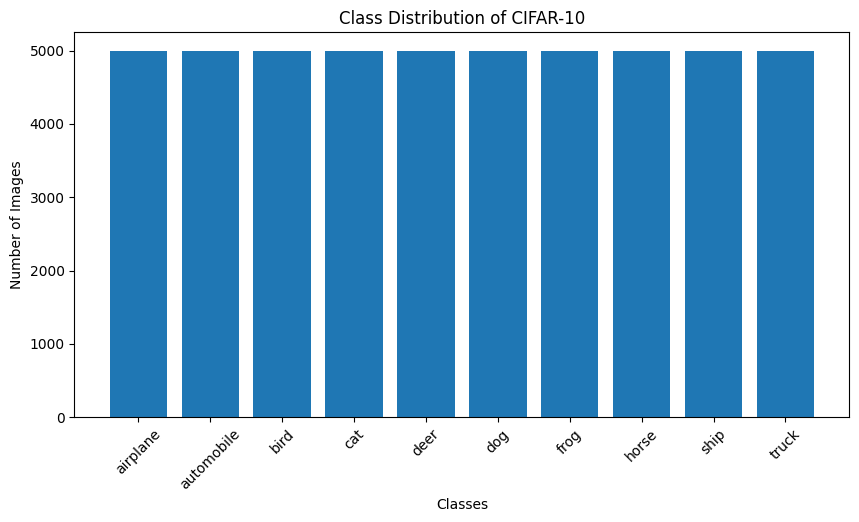

In [7]:
# Plot Class Distribution
labels = [label for _,label in train_dataset]

count = Counter(labels)

classes = train_dataset.classes

plt.figure(figsize = (10, 5))
plt.bar(classes, [count[i] for i in range(len(classes))])
plt.title("Class Distribution of CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

#### Task 2: Implement Convolutional Layer

In [8]:
import torch.nn as nn

In [9]:
# Take a Sample Image
image, label = train_dataset[0]
image = image.unsqueeze(0)

In [10]:
# Creating the Convolutional Layers

conv3 = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 3,
    stride = 1,
    padding = 0
)

conv5 = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 5,
    stride = 1,
    padding = 0
)

conv7 = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 7,
    stride = 1,
    padding = 0
)

In [11]:
# Perform the Convolution Operation
feature3 = conv3(image)
feature5 = conv5(image)
feature7 = conv7(image)

In [12]:
# Print the Resultant Dimensions
print("Input Image Shape: ", image.shape)
print("After 3x3 Filter: ", feature3.shape)
print("After 5x5 Filter: ", feature5.shape)
print("After 7x7 Filter: ", feature7.shape)

Input Image Shape:  torch.Size([1, 3, 32, 32])
After 3x3 Filter:  torch.Size([1, 1, 30, 30])
After 5x5 Filter:  torch.Size([1, 1, 28, 28])
After 7x7 Filter:  torch.Size([1, 1, 26, 26])


#### Task 3: Study Hyperparameter

In [13]:
# Using the same Sample Image

In [14]:
# Stride = 1
conv = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 3,
    stride = 1,
    padding = 0
)

feature = conv(image)

print("Input Image Shape: ", image.shape)
print("After 3x3 Filter with Stride of 1: ", feature.shape)

Input Image Shape:  torch.Size([1, 3, 32, 32])
After 3x3 Filter with Stride of 1:  torch.Size([1, 1, 30, 30])


In [15]:
# Stride = 2
conv = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 3,
    stride = 2,
    padding = 0
)

feature = conv(image)

print("Input Image Shape: ", image.shape)
print("After 3x3 Filter with Stride of 2: ", feature.shape)

Input Image Shape:  torch.Size([1, 3, 32, 32])
After 3x3 Filter with Stride of 2:  torch.Size([1, 1, 15, 15])


In [16]:
# Padding = 'same'
conv = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 3,
    stride = 1,
    padding = 'same'
)

feature = conv(image)

print("Input Image Shape: ", image.shape)
print("After 3x3 Filter with Padding of 'same': ", feature.shape)

Input Image Shape:  torch.Size([1, 3, 32, 32])
After 3x3 Filter with Padding of 'same':  torch.Size([1, 1, 32, 32])


In [17]:
# Stride = 1
conv = nn.Conv2d(
    in_channels = 3,
    out_channels = 1,
    kernel_size = 3,
    stride = 1,
    padding = 'valid'
)

feature = conv(image)

print("Input Image Shape: ", image.shape)
print("After 3x3 Filter with Padding of 'valid': ", feature.shape)

Input Image Shape:  torch.Size([1, 3, 32, 32])
After 3x3 Filter with Padding of 'valid':  torch.Size([1, 1, 30, 30])


#### Task 4: Visualize feature maps after the first convolution layer.

In [18]:
# Using the same Sample Image

In [19]:
# Creating the Convolutional Layer
conv = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3
)

In [20]:
# Performing the Convolution Operation
feature_maps = conv(image)

In [21]:
# Printing the Feature Map's Shape
feature_maps = feature_maps.squeeze(0)
print("Feature Map's Shape: ", feature_maps.shape)

Feature Map's Shape:  torch.Size([8, 30, 30])


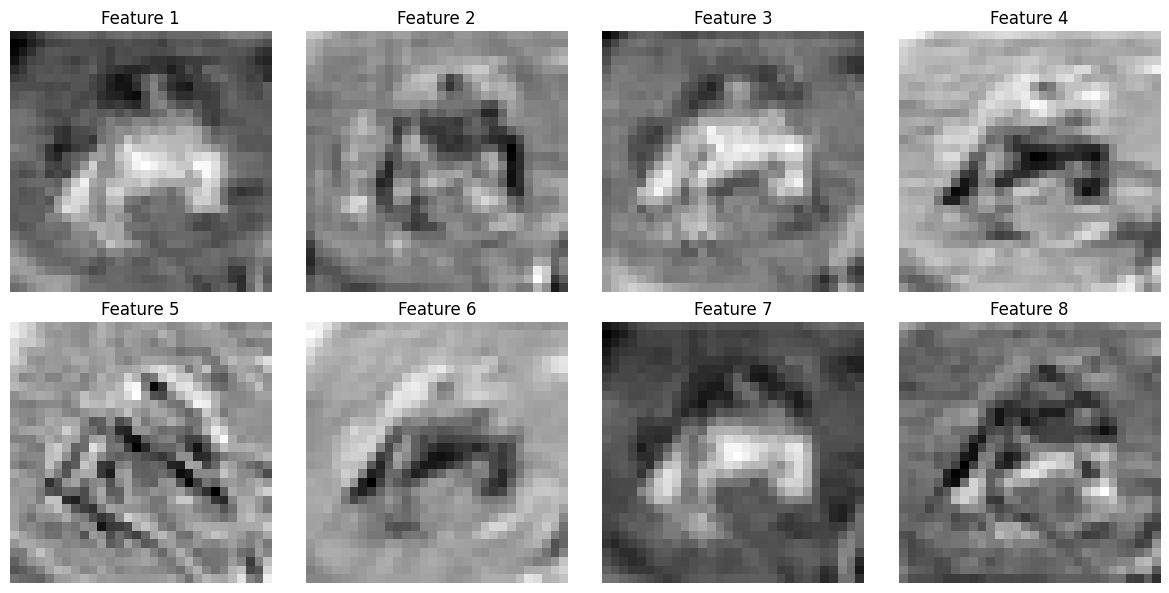

In [22]:
# Plot those Feature Maps

plt.figure(figsize = (12, 6))

for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(feature_maps[i].detach().numpy(), cmap = 'grey')
  plt.title(f'Feature {i+1}')
  plt.axis('off')

plt.tight_layout()
plt.show()

#### Task 5: Pooling

In [23]:
# Max Pooling
max_pool = nn.MaxPool2d(
    kernel_size = 2,
    stride = 2
)

max_output = max_pool(feature_maps)
print(max_output.shape)

torch.Size([8, 15, 15])


In [24]:
# Avg Pooling
avg_pool = nn.AvgPool2d(
    kernel_size = 2,
    stride = 2
)

avg_output = avg_pool(feature_maps)
print(avg_output.shape)

torch.Size([8, 15, 15])


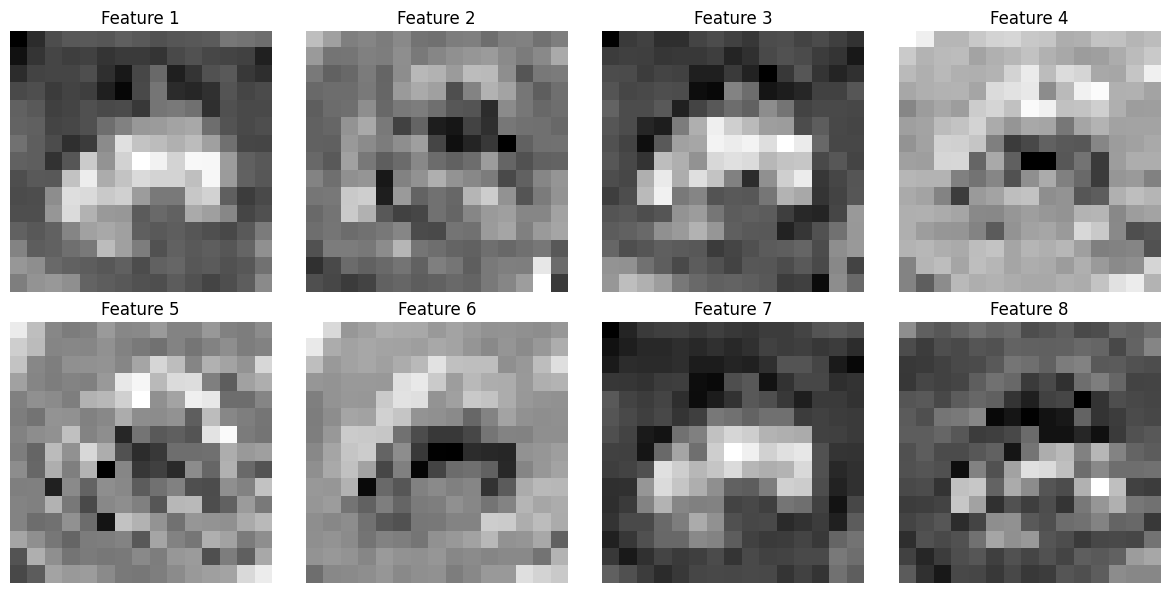

In [25]:
# Visualizing the difference - max_pool

plt.figure(figsize = (12, 6))

for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(max_output[i].detach().numpy(), cmap = 'grey')
  plt.title(f'Feature {i+1}')
  plt.axis('off')

plt.tight_layout()
plt.show()

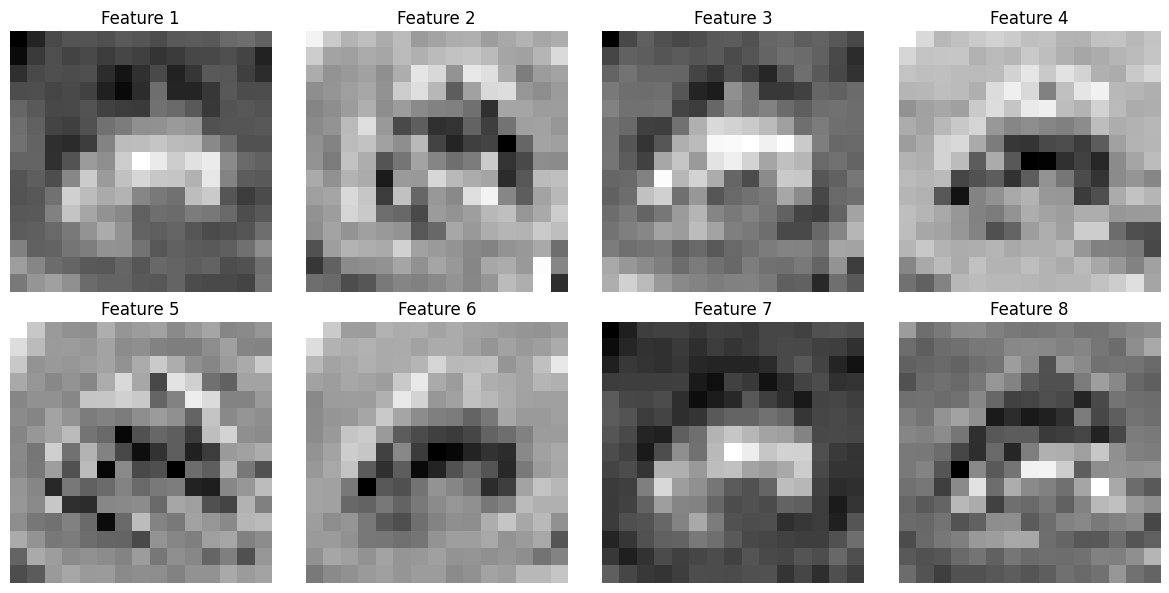

In [26]:
# Visualizing the difference - avg_pool

plt.figure(figsize = (12, 6))

for i in range(8):
  plt.subplot(2, 4, i+1)
  plt.imshow(avg_output[i].detach().numpy(), cmap = 'grey')
  plt.title(f'Feature {i+1}')
  plt.axis('off')

plt.tight_layout()
plt.show()

#### Task 6: CNN Implementation and Training

In [44]:
# CNN Class

class CNN(nn.Module):

  def __init__(self):

    super().__init__()

    self.features = nn.Sequential(

        nn.Conv2d(
            in_channels = 3,
            out_channels = 8,
            kernel_size = 3,
            padding = 1
        ),

        nn.ReLU(),

        nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        ),

        nn.Conv2d(
            in_channels = 8,
            out_channels = 16,
            kernel_size = 3,
            padding = 1
        ),

        nn.ReLU(),

        nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )

    )

    self.classifier = nn.Sequential(

        nn.Flatten(),

        nn.Linear(
            16*8*8,
            10
        )

    )


  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [45]:
# Create the model
model = CNN()
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=10, bias=True)
  )
)


In [46]:
# Create Data Loader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    validation_subset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [47]:
# Loss Function
criterion = nn.CrossEntropyLoss()

In [48]:
# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [51]:
# Training loop
epochs = 20

train_loss_history = []
train_accuracy_history = []
validation_loss_history = []
validation_accuracy_history = []

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    validation_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            validation_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_validation_loss = validation_loss / len(validation_loader)
    epoch_validation_accuracy = 100 * correct / total

    # =========================
    # STORING
    # =========================

    train_loss_history.append(epoch_train_loss)
    train_accuracy_history.append(epoch_train_accuracy)
    validation_loss_history.append(epoch_validation_loss)
    validation_accuracy_history.append(epoch_validation_accuracy)

    # =========================
    # PRINTING
    # =========================
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Train Acc: {epoch_train_accuracy:.2f}% "
        f"Val Loss: {epoch_validation_loss:.4f} "
        f"Val Acc: {epoch_validation_accuracy:.2f}%"
    )

Epoch [1/20] Train Loss: 1.2679 Train Acc: 55.41% Val Loss: 1.2059 Val Acc: 58.56%
Epoch [2/20] Train Loss: 1.1950 Train Acc: 58.31% Val Loss: 1.1383 Val Acc: 60.84%
Epoch [3/20] Train Loss: 1.1431 Train Acc: 60.13% Val Loss: 1.0950 Val Acc: 62.58%
Epoch [4/20] Train Loss: 1.1029 Train Acc: 61.62% Val Loss: 1.0364 Val Acc: 64.66%
Epoch [5/20] Train Loss: 1.0708 Train Acc: 62.74% Val Loss: 1.0305 Val Acc: 65.18%
Epoch [6/20] Train Loss: 1.0503 Train Acc: 63.68% Val Loss: 1.0067 Val Acc: 65.20%
Epoch [7/20] Train Loss: 1.0337 Train Acc: 64.16% Val Loss: 1.0011 Val Acc: 65.40%
Epoch [8/20] Train Loss: 1.0151 Train Acc: 64.73% Val Loss: 0.9736 Val Acc: 66.84%
Epoch [9/20] Train Loss: 1.0006 Train Acc: 65.42% Val Loss: 0.9742 Val Acc: 66.52%
Epoch [10/20] Train Loss: 0.9936 Train Acc: 65.46% Val Loss: 0.9802 Val Acc: 66.32%
Epoch [11/20] Train Loss: 0.9850 Train Acc: 65.90% Val Loss: 0.9766 Val Acc: 66.68%
Epoch [12/20] Train Loss: 0.9730 Train Acc: 66.36% Val Loss: 0.9396 Val Acc: 67.40%
E

#### Task 7: CNN Evaluation

In [52]:
# Import
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [53]:
# Testing loop
model.eval()

all_predictions = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

In [54]:
# Accuracy
accuracy = 100 * correct / total

In [55]:
# Precision
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

In [56]:
# Recall
recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

In [57]:
# F1 Score
f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

In [58]:
# Printing Scores
print(f"Accuracy: {accuracy:.4f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy: 63.2100%
Precision : 0.6406
Recall    : 0.6321
F1 Score  : 0.6302


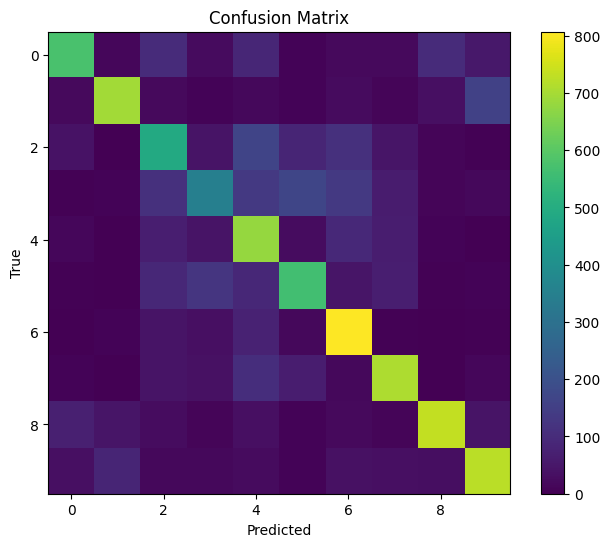

In [59]:
# Confusion Matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

In [60]:
# Classification Report
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

    airplane       0.74      0.57      0.65      1000
  automobile       0.81      0.69      0.75      1000
        bird       0.49      0.49      0.49      1000
         cat       0.51      0.35      0.41      1000
        deer       0.48      0.68      0.56      1000
         dog       0.59      0.56      0.58      1000
        frog       0.62      0.81      0.70      1000
       horse       0.68      0.71      0.70      1000
        ship       0.79      0.73      0.76      1000
       truck       0.70      0.72      0.71      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.63     10000
weighted avg       0.64      0.63      0.63     10000



#### Visualization

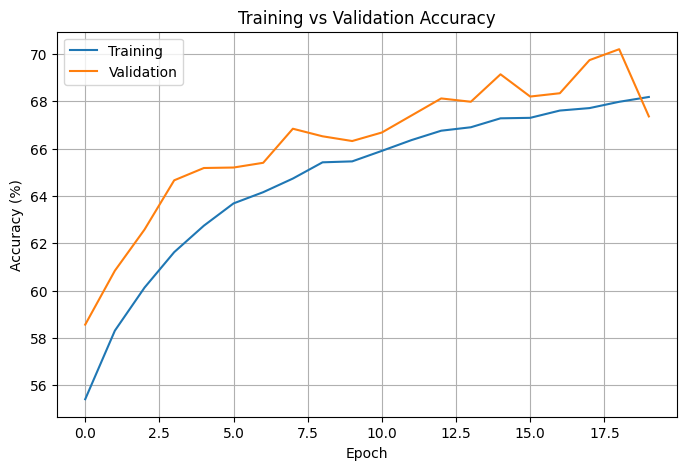

In [61]:
# Training Accuracy vs Validation Accuracy

plt.figure(figsize=(8,5))
plt.plot(train_accuracy_history, label="Training")
plt.plot(validation_accuracy_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

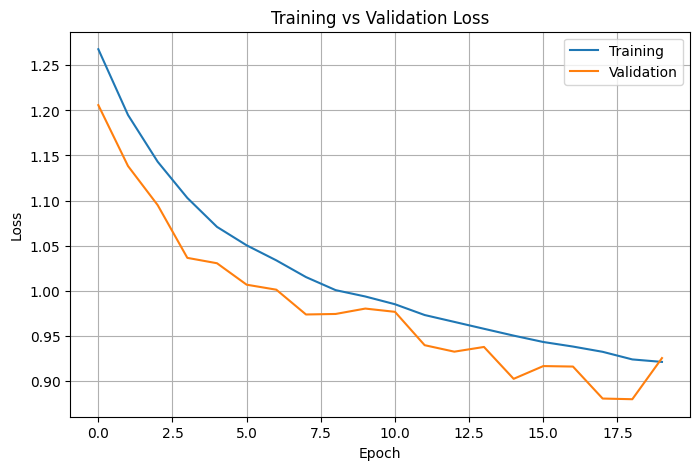

In [62]:
# Training Loss vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="Training")
plt.plot(validation_loss_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()